In [1]:
import sys
import numpy as np
import anndata as ad
import polars as pl
import pickle

import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rna_full = ad.read_h5ad('private/data/snRNAseq-nogonad.h5ad')
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
atac_e = ad.read_h5ad('private/data/imp2025/emb-2-atac.h5ad')

In [3]:
rna_mutant=rna_full[(rna_full.obs.rep == 'kd_r1') + (rna_full.obs.rep == 'kd_r2')].copy()
rna_mutant.layers['rna'] = rna_mutant.X.copy()
del rna_mutant.X
rna_wt=rna_full[(rna_full.obs.rep == 'c_r1') + (rna_full.obs.rep == 'c_r2')].copy()
rna_wt.layers['rna'] = rna_wt.X.copy()
del rna_wt.X
del rna_full

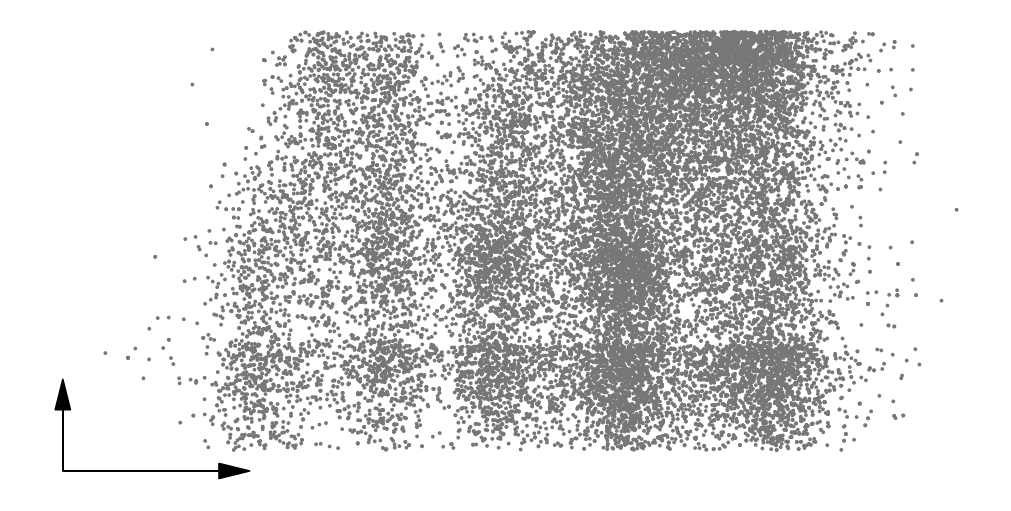

In [5]:
scit.pl.embedding2d(cttag, 'X_landscape')

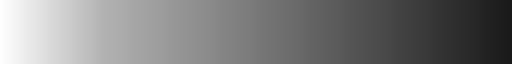

In [7]:
cmap_g = scit.adv.pl.custom_cmap('gray')
cmap_c = scit.adv.pl.custom_cmap('with_color')
bwr = scit.adv.pl.custom_cmap('bwr')
cmap_g

In [8]:
active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()

In [9]:
lc_acet = scit.tl.make_layer_config(
    "acet_imp",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth_imp",
    in_obsm=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

Info: Added Griddata to .uns[cat_label]
Info: [x] grid trimmed from 36 to 36
Info: [y] grid trimmed from 29 to 29


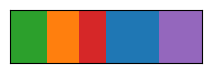

Info: Added Griddata to .uns[cat_label]


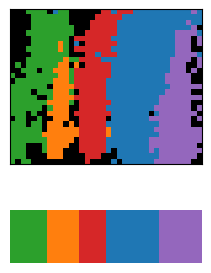

In [10]:
scit.set_defaults(figsize=(2,3))

MINCELL_CT = 8
MINCELL_RNA = 2

# cttag = cttag[cttag.obsm['X_landscape'][:,1] < -12]
# scit.adv.make_grid(cttag, (50, 20))
scit.adv.griddata_categorical(cttag, 'label', min_cells=MINCELL_CT)
scit.adv.make_color_summary(cttag, 50, 'cat_label', min_cells_y=200, y_fraction=0.4)

scit.adv.griddata_categorical(cttag, 'label', MINCELL_CT)
scit.adv.pl.categorical2d(cttag, 'cat_label')

In [11]:
from copy import deepcopy
grid_bkup = deepcopy(cttag.uns['grid'])

In [12]:


cttag.uns['grid'] = deepcopy(grid_bkup)
cttag.uns['grid']['xy']=[
    cttag.uns['grid']['xy'][0][:,:15],
    cttag.uns['grid']['xy'][1][:,:15]
]
cttag.uns['grid']['resolution'] = [36, 15]

Info: Added Griddata to .uns[cat_label]


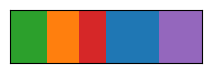

Info: Added Griddata to .uns[cat_label]


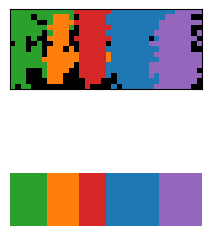

In [13]:
scit.adv.griddata_categorical(cttag, 'label', min_cells=MINCELL_CT)
scit.adv.make_color_summary(cttag, 0, 'cat_label', min_cells_y=None, y_fraction=0.4)

scit.adv.griddata_categorical(cttag, 'label', MINCELL_CT)
scit.adv.pl.categorical2d(cttag, 'cat_label')

In [14]:
s = cttag.uns['gene_names_acet'][active_meth]
scit.tl.layer_pick_features(cttag, lc_acet, s)
scit.tl.layer_pick_features(cttag, lc_meth, s)

scit.adv.griddata_numerical(cttag, lc_meth, min_cells=MINCELL_CT)
scit.adv.griddata_numerical(cttag, lc_acet, min_cells=MINCELL_CT)

Info: Added Griddata to .uns[meth_imp]
Info: Added Griddata to .uns[acet_imp]


In [15]:
trs = dict(
    gauss_kernel=(1.5,1.5), upscale_factor=2, n_median_passes=1
)
krl = (0.5,0.5)
dscl = (30, 3)

scit.adv.griddata_apply_transformations(cttag, lc_meth.layer, data_scalar=dscl[0], **trs)
scit.adv.griddata_apply_transformations(cttag, lc_acet.layer, data_scalar=dscl[1], **trs)

t_acet = f"t_{lc_acet.layer}"
t_meth = f"t_{lc_meth.layer}"

from copy import deepcopy
ACET_SCL = 2

cttag.uns['griddata']['t_epi'] = deepcopy(cttag.uns['griddata'][t_meth])
cttag.uns['griddata']['t_epi']['z'] = cttag.uns['griddata'][t_meth]['z'] - ACET_SCL*cttag.uns['griddata'][t_acet]['z']

Info: Scaling by 2x: from (36, 15) to (72, 30)
Info: Added Griddata to .uns[t_meth_imp]
Info: Scaling by 2x: from (36, 15) to (72, 30)
Info: Added Griddata to .uns[t_acet_imp]


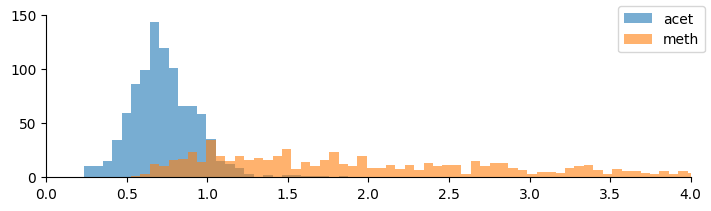

In [17]:
scit.set_defaults(figsize=(7,2))
scit.pl.int.histogram(
    [
    cttag.uns['griddata'][t_acet]['z'].mean(axis=(1,2)),
    cttag.uns['griddata'][t_meth]['z'].mean(axis=(1,2)),
    ],
    [
        'acet', 'meth', 'rna'
    ], xminmax=(0,4), bins=300
)

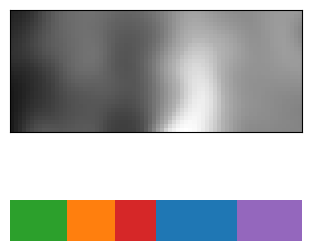

In [18]:
scit.set_defaults(figsize=(3,3))

gn = "vvl"

scit.adv.pl.landscape2d(cttag, 't_epi', gn, cmap=cmap_g)

In [19]:
mt_lsc = ad.read_h5ad('private/data/clean_method/mutant_landscape.h5ad')
# mt_lsc = mt_lsc[mt_lsc.obsm['X_landscape'][:,1] < -12].copy()

Info: Added Griddata to .uns[cat_label]


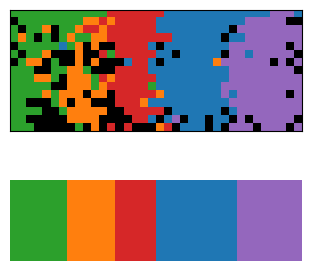

In [20]:
scit.adv.same_grid((cttag, mt_lsc))
scit.adv.griddata_categorical(mt_lsc, 'label', 5)
scit.adv.pl.categorical2d(mt_lsc, 'cat_label')

In [21]:
scit.tl.layer_pick_features(mt_lsc, lc_acet, s)
scit.tl.layer_pick_features(mt_lsc, lc_meth, s)
scit.adv.griddata_numerical(mt_lsc, lc_meth, min_cells=MINCELL_CT)
scit.adv.griddata_numerical(mt_lsc, lc_acet, min_cells=MINCELL_CT)

Info: Added Griddata to .uns[meth_imp]
Info: Added Griddata to .uns[acet_imp]


In [22]:
scit.adv.griddata_apply_transformations(mt_lsc, lc_meth.layer, data_scalar=dscl[0]-3, **trs)
scit.adv.griddata_apply_transformations(mt_lsc, lc_acet.layer, data_scalar=dscl[1], **trs)


mt_lsc.uns['griddata']['t_epi'] = deepcopy(mt_lsc.uns['griddata'][t_meth])
mt_lsc.uns['griddata']['t_epi']['z'] = mt_lsc.uns['griddata'][t_meth]['z'] - ACET_SCL*mt_lsc.uns['griddata'][t_acet]['z']

Info: Scaling by 2x: from (36, 15) to (72, 30)
Info: Added Griddata to .uns[t_meth_imp]
Info: Scaling by 2x: from (36, 15) to (72, 30)
Info: Added Griddata to .uns[t_acet_imp]


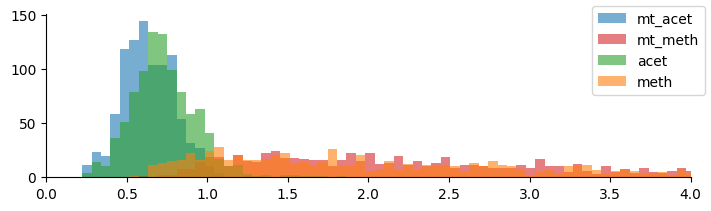

In [23]:
scit.set_defaults(figsize=(7,2))
scit.pl.int.histogram(
    [
    mt_lsc.uns['griddata'][t_acet]['z'].mean(axis=(1,2)),
    mt_lsc.uns['griddata'][t_meth]['z'].mean(axis=(1,2)),
    cttag.uns['griddata'][t_acet]['z'].mean(axis=(1,2)),
    cttag.uns['griddata'][t_meth]['z'].mean(axis=(1,2))
    ],
    [
        'mt_acet', 'mt_meth', 'acet', 'meth'
    ], colors=['tab:blue', 'tab:red', 'tab:green', 'tab:orange'], xminmax=(0,4), bins=300
)

In [25]:
assert mt_lsc.uns['griddata']['t_epi']['z'].max() == 24.79478

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/tmp/nix-shell-59330-0/ipykernel_98433/144114424.py:10: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.gcf().savefig(f'private/newest/screenshots/{gn}_mt.png', dpi=300)
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/tmp/nix-shell-59330-0/ipykernel_98433/144114424.py:18: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.

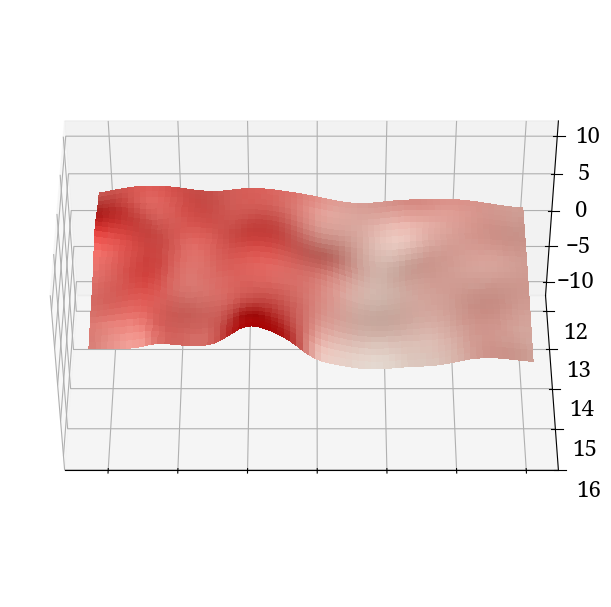

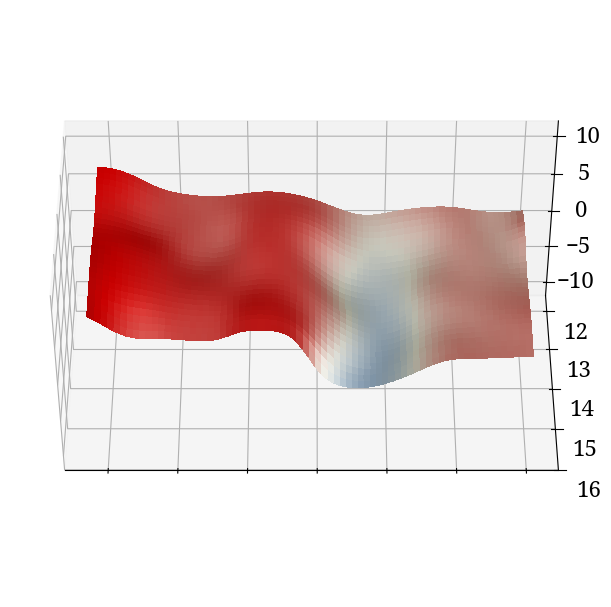

In [29]:
scit.set_defaults(figsize=(4,3))
gn = 'vvl'
# scit.adv.pl.landscape3d(cttag, 't_epi', gn, cmap=cmap_g, vminmax=(0,20))
scit.adv.pl.landscape3d(
    mt_lsc.uns['griddata']['t_epi'], gn, cmap=bwr,  vminmax=(-12,12), #vminmax=(-4,8),#
    ticksize=16,
    show=False, fontname="Noto Serif", label_pad=6, x_aspect=2
)
import matplotlib.pyplot as plt
plt.gcf().savefig(f'private/newest/screenshots/{gn}_mt.png', dpi=300)

scit.adv.pl.landscape3d(
    cttag.uns['griddata']['t_epi'], gn, cmap=bwr,  vminmax=(-12,12), #vminmax=(-4,8),#
    ticksize=16,
    show=False, fontname="Noto Serif", label_pad=6, x_aspect=2
)
import matplotlib.pyplot as plt
plt.gcf().savefig(f'private/newest/screenshots/{gn}_wt.png', dpi=300)

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/tmp/nix-shell-59330-0/ipykernel_98433/4156579761.py:10: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  plt.gcf().savefig(f'private/newest/screenshots/{gn}_mt_meth.png', dpi=300)
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/tmp/nix-shell-59330-0/ipykernel_98433/4156579761.py:18: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.

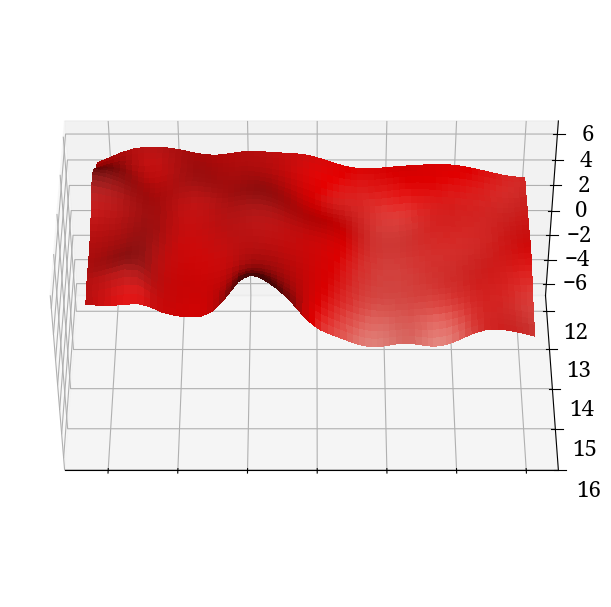

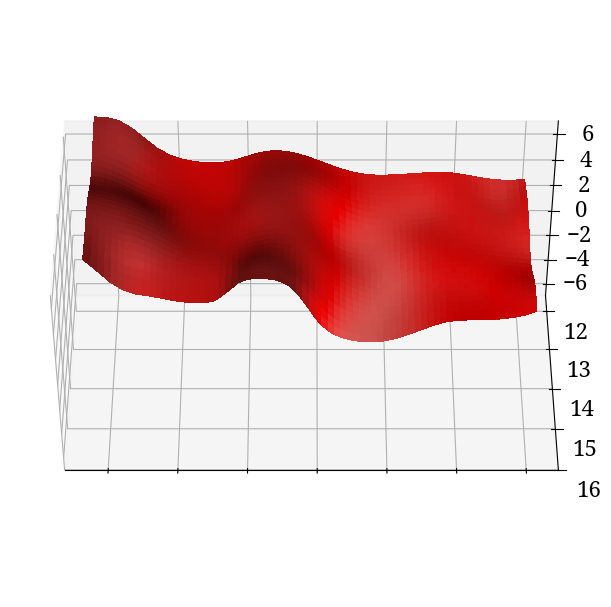

In [28]:
scit.set_defaults(figsize=(4,3))
gn = 'vvl'
# scit.adv.pl.landscape3d(cttag, 't_epi', gn, cmap=cmap_g, vminmax=(0,20))
scit.adv.pl.landscape3d(
    mt_lsc.uns['griddata'][t_meth], gn, cmap=bwr,  vminmax=(-7,7), #vminmax=(-4,8),#
    ticksize=16,
    show=False, fontname="Noto Serif", label_pad=6, x_aspect=2
)
import matplotlib.pyplot as plt
plt.gcf().savefig(f'private/newest/screenshots/{gn}_mt_meth.png', dpi=300)

scit.adv.pl.landscape3d(
    cttag.uns['griddata'][t_meth], gn, cmap=bwr,  vminmax=(-7,7), #vminmax=(-4,8),#
    ticksize=16,
    show=False, fontname="Noto Serif", label_pad=6, x_aspect=2
)
import matplotlib.pyplot as plt
plt.gcf().savefig(f'private/newest/screenshots/{gn}_wt_meth.png', dpi=300)

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  fig.canvas.print_figure(bytes_io, **kw)


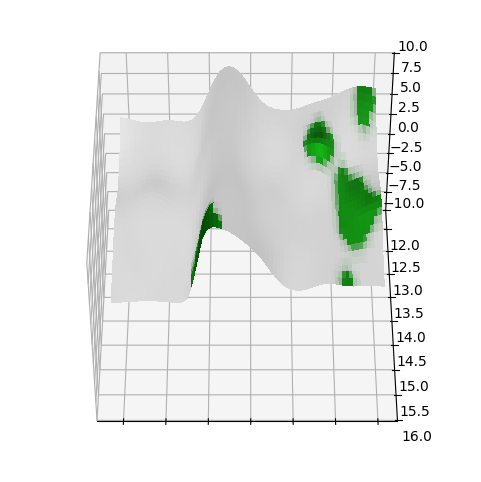

In [129]:
scit.set_defaults(figsize=(3,3))
gn = "Kr"
scit.adv.pl.landscape3d(
    cttag.uns['griddata']['t_epi'], gn, cmap=cmap_g,  vminmax=(-10,10), #vminmax=(-4,8),#
    shade_data=rna_wt.uns['griddata'][t_rna], shade_cmap=cmap_c, extra_shade_weight=3, shade_vminmax=(0,0.005) #shade_vminmax=(0,7), 
)

In [ ]:
scit.set_defaults(figsize=(3,3))
from src.advanced._griddata import _get_griddata_z
import matplotlib.pyplot as plt
gns = cttag.uns['gene_names_acet'][active_meth]# [582:] #[active_meth]

for gn in gns:
    if gn not in rna_mutant.uns['griddata'][t_rna]['feature_names']:
        continue
    _z = _get_griddata_z(cttag.uns['griddata']['t_epi'], gn)
    _zr = _get_griddata_z(rna_wt.uns['griddata'][t_rna], gn)
    if _zr.sum() < 2:
        continue
    vmx = (_z.min()-1, _z.max()+1)
    vmx_s = (0, _zr.max())
    f=scit.adv.pl.landscape3d(cttag.uns['griddata']['t_epi'], gn, cmap=cmap_g, 
        shade_data=rna_wt.uns['griddata'][t_rna], shade_cmap=cmap_c, extra_shade_weight=2,
        vminmax=vmx, shade_vminmax=vmx_s,show=False)
    f.savefig(f'private/newest/mutrna_lands/{gn}_wt.png')
    f=scit.adv.pl.landscape3d(mt_lsc.uns['griddata']['t_epi'], gn, cmap=cmap_g, 
        shade_data=rna_mutant.uns['griddata'][t_rna], shade_cmap=cmap_c, extra_shade_weight=2,
        vminmax=vmx, shade_vminmax=vmx_s, show=False)
    f.savefig(f'private/newest/mutrna_lands/{gn}_mt.png')
    plt.close('all')
    import gc; gc.collect()

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/tmp/nix-shell-223965-0/ipykernel_259501/992208219.py:18: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  f.savefig(f'private/newest/mutrna_lands/{gn}_wt.png')
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/tmp/nix-shell-223965-0/ipykernel_259501/992208219.py:22: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  f.savefig(f'privat

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fdbe9597a10>>
Traceback (most recent call last):
  File "/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/advanced/plotting/_3d.py:98: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([l.get_text()[1:] for l in lbl])
/tmp/nix-shell-223965-0/ipykernel_259501/992208219.py:18: UserWarning: constrained_layout not applied because axes sizes collapsed to zero.  Try making figure larger or Axes decorations smaller.
  f.savefig(f'private/newest/mutrna_lands/{gn}_wt.png')
